# Fake News Detection 
### Internship Project — B.Tech Data Science

This notebook implements an end-to-end NLP and Machine Learning workflow for preliminary classification of news text as **Likely Fake** or **Likely Real**.

> **Important:** This is an ML classifier, not an independent fact-checker. Predictions depend on the training dataset and should not be treated as proof of truth or falsehood.


## Project Workflow
Dataset acquisition → EDA → cleaning → NLP preprocessing → train/test split → TF-IDF → model comparison → evaluation → error analysis → model saving → interactive prediction.


In [1]:
# 1. Install dependencies if required
# Uncomment once in a fresh environment:
# %pip install pandas numpy scikit-learn matplotlib seaborn joblib requests

import re, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
warnings.filterwarnings("ignore")

DATA=Path("data/WELFake_Dataset.csv"); MODELS=Path("models"); RESULTS=Path("results")
MODELS.mkdir(exist_ok=True); RESULTS.mkdir(exist_ok=True)
print("Environment ready.")


Environment ready.


In [2]:
# 2. Download WELFake dataset automatically
# The published file is large (~245 MB), so the first run can take several minutes.
DATA_URL="https://zenodo.org/records/4561253/files/WELFake_Dataset.csv?download=1"
if not DATA.exists():
    import requests
    print("Downloading dataset...")
    r=requests.get(DATA_URL,stream=True,timeout=120); r.raise_for_status()
    total=int(r.headers.get("content-length",0)); done=0
    with open(DATA,"wb") as f:
        for chunk in r.iter_content(1024*1024):
            if chunk:
                f.write(chunk); done+=len(chunk)
                if total: print(f"{done/1048576:.1f} / {total/1048576:.1f} MB",end="\\r")
    print("\\nDownload complete.")
else: print("Dataset already present.")


\nDownload complete.


In [3]:
# 3. Load and inspect
df=pd.read_csv(DATA)
df.columns=[c.strip().lower() for c in df.columns]
print("Shape:",df.shape)
display(df.head())
print("\nMissing values:")
display(df.isna().sum())


Shape: (72134, 4)


,unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1



Missing values:


unnamed: 0      0
title         558
text           39
label           0
dtype: int64

In [4]:
# 4. Clean and standardize
needed={"title","text","label"}
missing=needed-set(df.columns)
if missing: raise ValueError(f"Missing columns: {missing}")
df=df[["title","text","label"]].copy()
df["title"]=df["title"].fillna(""); df["text"]=df["text"].fillna("")
df["label"]=pd.to_numeric(df["label"],errors="coerce")
df=df.dropna(subset=["label"]); df["label"]=df["label"].astype(int)
df["combined_text"]=(df["title"]+" "+df["text"]).str.strip()
df=df[df["combined_text"].str.len()>=20].drop_duplicates("combined_text").reset_index(drop=True)
print("Clean dataset:",df.shape)
display(df["label"].map({0:"Fake",1:"Real"}).value_counts())


Clean dataset: (63636, 4)


label
Fake    34790
Real    28846
Name: count, dtype: int64

## Exploratory Data Analysis

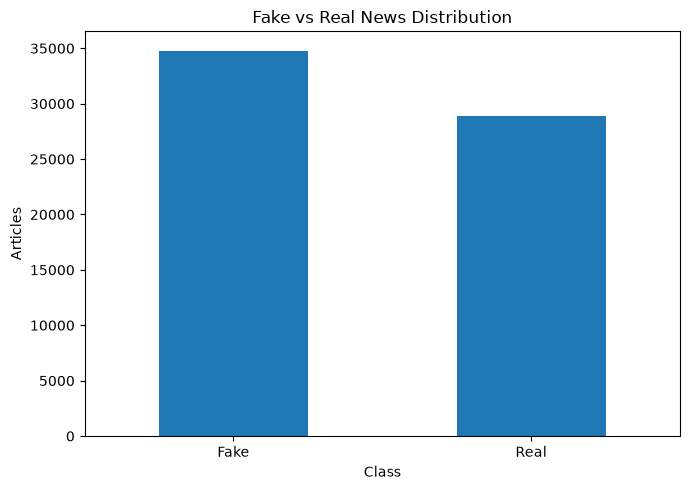

In [5]:
# 5. Class distribution
counts=df["label"].map({0:"Fake",1:"Real"}).value_counts()
ax=counts.plot(kind="bar",figsize=(7,5))
plt.title("Fake vs Real News Distribution"); plt.xlabel("Class"); plt.ylabel("Articles")
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(RESULTS/"class_distribution.png",dpi=200); plt.show()


,count,mean,median,min,max
label,,,,,
Fake,34790,589.318942,438.0,4,14650
Real,28846,512.595507,388.0,2,24243


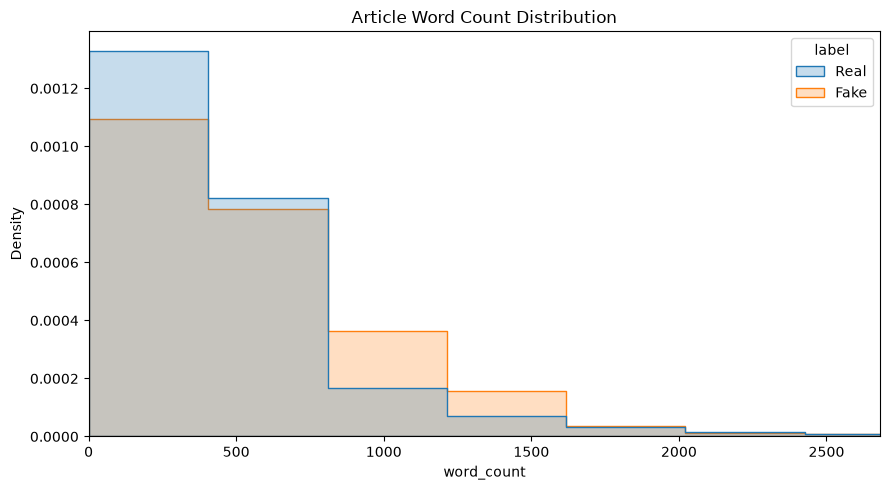

In [6]:
# 6. Article length analysis
df["word_count"]=df["combined_text"].str.split().str.len()
display(df.groupby("label")["word_count"].agg(["count","mean","median","min","max"]).rename(index={0:"Fake",1:"Real"}))
plt.figure(figsize=(9,5))
sns.histplot(data=df,x="word_count",hue=df["label"].map({0:"Fake",1:"Real"}),bins=60,element="step",stat="density",common_norm=False)
plt.xlim(0,df["word_count"].quantile(.99)); plt.title("Article Word Count Distribution"); plt.tight_layout()
plt.savefig(RESULTS/"word_count_distribution.png",dpi=200); plt.show()


## NLP Preprocessing

In [7]:
# 7. Text cleaning
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r"http\S+|www\S+"," ",text)
    text=re.sub(r"<.*?>"," ",text)
    text=re.sub(r"[^a-z\s]"," ",text)
    return re.sub(r"\s+"," ",text).strip()
df["clean_text"]=df["combined_text"].apply(clean_text)
display(df[["combined_text","clean_text","label"]].head(3))


,combined_text,clean_text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...,1
1,Did they post their votes for Hillary already?,did they post their votes for hillary already,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama s attorney general says mos...,1


In [8]:
# 8. Train/test split
X_train,X_test,y_train,y_test=train_test_split(
    df["clean_text"],df["label"],test_size=.20,random_state=42,stratify=df["label"]
)
print("Training:",len(X_train)," Testing:",len(X_test))


Training: 50908  Testing: 12728


## TF-IDF Feature Extraction

In [9]:
# 9. TF-IDF
vectorizer=TfidfVectorizer(max_features=100000,ngram_range=(1,2),min_df=2,max_df=.95,sublinear_tf=True,stop_words="english")
Xtr=vectorizer.fit_transform(X_train); Xte=vectorizer.transform(X_test)
print("Training matrix:",Xtr.shape," Test matrix:",Xte.shape)


Training matrix: (50908, 100000)  Test matrix: (12728, 100000)


In [10]:
# 10. Train three models
models={
"Logistic Regression":LogisticRegression(max_iter=1000,random_state=42),
"Multinomial Naive Bayes":MultinomialNB(),
"Linear SVM":LinearSVC(random_state=42)
}
rows=[]; fitted={}
for name,m in models.items():
    print("Training:",name)
    m.fit(Xtr,y_train); p=m.predict(Xte); fitted[name]=m
    rows.append({"Model":name,"Accuracy":accuracy_score(y_test,p),"Precision":precision_score(y_test,p,zero_division=0),"Recall":recall_score(y_test,p,zero_division=0),"F1 Score":f1_score(y_test,p,zero_division=0)})
comparison=pd.DataFrame(rows).sort_values("F1 Score",ascending=False).reset_index(drop=True)
display(comparison.style.format("{:.4f}",subset=["Accuracy","Precision","Recall","F1 Score"]))
comparison.to_csv(RESULTS/"model_comparison.csv",index=False)


Training: Logistic Regression
Training: Multinomial Naive Bayes
Training: Linear SVM


,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.9672,0.9635,0.9643,0.9639
1,Logistic Regression,0.9558,0.9532,0.9492,0.9512
2,Multinomial Naive Bayes,0.8876,0.8708,0.8832,0.8770


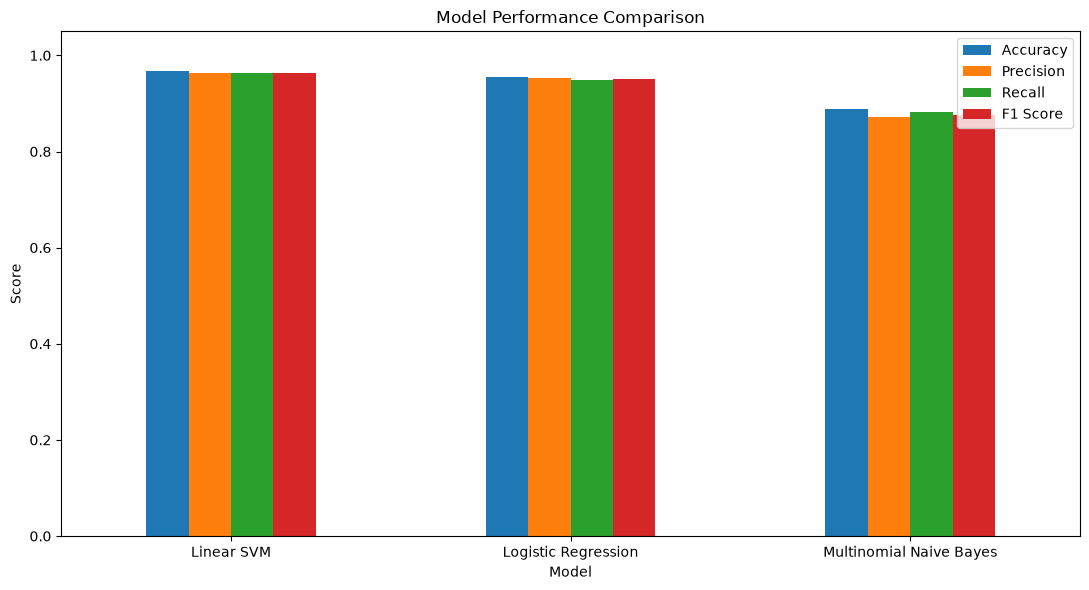

In [11]:
# 11. Model comparison chart
comparison.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind="bar",figsize=(11,6))
plt.title("Model Performance Comparison"); plt.ylabel("Score"); plt.ylim(0,1.05); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(RESULTS/"model_comparison.png",dpi=200); plt.show()


In [12]:
# 12. Select model by measured F1 score
best_name=comparison.iloc[0]["Model"]; best_model=fitted[best_name]
best_pred=best_model.predict(Xte)
print("Selected model:",best_name)
print(classification_report(y_test,best_pred,target_names=["Fake","Real"],digits=4,zero_division=0))


Selected model: Linear SVM
              precision    recall  f1-score   support

        Fake     0.9704    0.9697    0.9700      6958
        Real     0.9635    0.9643    0.9639      5770

    accuracy                         0.9672     12728
   macro avg     0.9669    0.9670    0.9670     12728
weighted avg     0.9672    0.9672    0.9672     12728



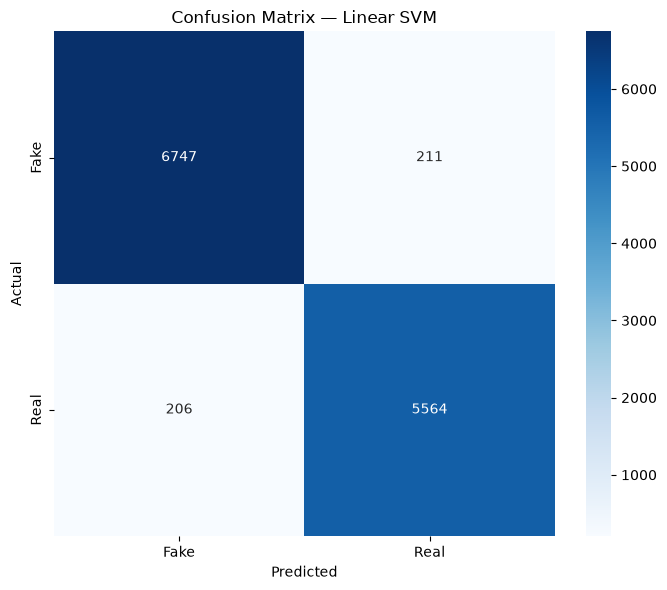

In [13]:
# 13. Confusion matrix
cm=confusion_matrix(y_test,best_pred,labels=[0,1])
plt.figure(figsize=(7,6)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Fake","Real"],yticklabels=["Fake","Real"])
plt.title("Confusion Matrix — "+best_name); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout()
plt.savefig(RESULTS/"confusion_matrix.png",dpi=200); plt.show()


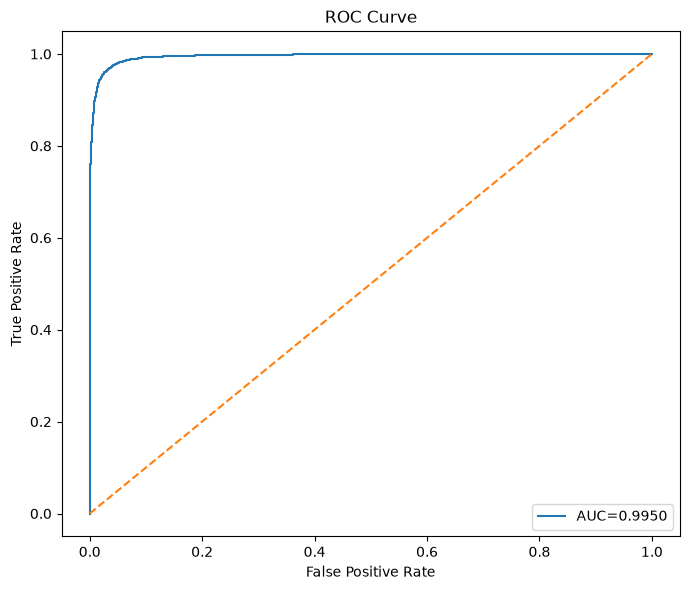

ROC-AUC: 0.9949824472958074


In [14]:
# 14. ROC-AUC
scores=best_model.decision_function(Xte) if hasattr(best_model,"decision_function") else best_model.predict_proba(Xte)[:,1]
auc=roc_auc_score(y_test,scores); fpr,tpr,_=roc_curve(y_test,scores)
plt.figure(figsize=(7,6)); plt.plot(fpr,tpr,label=f"AUC={auc:.4f}"); plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve"); plt.legend(); plt.tight_layout()
plt.savefig(RESULTS/"roc_curve.png",dpi=200); plt.show(); print("ROC-AUC:",auc)


## Error Analysis

In [15]:
# 15. Inspect misclassified examples
errors=pd.DataFrame({"text":X_test.values,"actual":y_test.values,"predicted":best_pred})
errors=errors[errors.actual!=errors.predicted]
print("Misclassified articles:",len(errors))
display(errors.head(10))
errors.to_csv(RESULTS/"misclassified_articles.csv",index=False)


Misclassified articles: 417


,text,actual,predicted
44,cnn host doesn t recognize star spangled banne...,1,0
55,it begins rino mega donor threatens jeb bush n...,1,0
112,why the gop establishment should fear this out...,1,0
118,islamic terrorist organization joins obama and...,1,0
152,donald trump is going to be elected donald tru...,0,1
156,texas troopers to ask drivers their race follo...,0,1
238,four afghans found guilty of raping lost year ...,0,1
248,moms whose children were killed by illegals to...,1,0
249,the pecan steps off the pie plate the new york...,0,1
293,has hillary clinton outstayed her welcome at t...,0,1


In [16]:
# 16. Save model, vectorizer and metrics
joblib.dump(best_model,MODELS/"fake_news_model.joblib")
joblib.dump(vectorizer,MODELS/"tfidf_vectorizer.joblib")
metrics={
"selected_model":best_name,"accuracy":float(accuracy_score(y_test,best_pred)),
"precision":float(precision_score(y_test,best_pred,zero_division=0)),
"recall":float(recall_score(y_test,best_pred,zero_division=0)),
"f1_score":float(f1_score(y_test,best_pred,zero_division=0)),
"roc_auc":float(auc),"train_samples":len(X_train),"test_samples":len(X_test)
}
(RESULTS/"metrics.json").write_text(json.dumps(metrics,indent=2))
print(metrics)


{'selected_model': 'Linear SVM', 'accuracy': 0.9672375864236329, 'precision': 0.9634632034632035, 'recall': 0.9642980935875216, 'f1_score': 0.9638804677349502, 'roc_auc': 0.9949824472958074, 'train_samples': 50908, 'test_samples': 12728}


## Interactive Prediction

In [17]:
# 17. Predict new news
def predict_news(news):
    model=joblib.load(MODELS/"fake_news_model.joblib")
    vec=joblib.load(MODELS/"tfidf_vectorizer.joblib")
    features=vec.transform([clean_text(news)])
    pred=int(model.predict(features)[0])
    return "Likely Real" if pred==1 else "Likely Fake"

sample="The government announced a new public education initiative after an official review."
print("Sample prediction:",predict_news(sample))


Sample prediction: Likely Real


In [ ]:
# 18. Enter your own article/headline
news=input("Paste news headline/article: ").strip()
if news: print("Prediction:",predict_news(news))
else: print("No text entered.")


## Conclusion and Future Scope
The project implements a complete NLP/ML pipeline from data acquisition to prediction. Future improvements can include multilingual NLP, transformer models, source-credibility features, explainable AI and real-time verification.

**Limitation:** the classifier learns from its dataset and cannot independently verify real-world claims.
